In [1]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. PATHS & DATASET CLASS
# ==========================================
BASE_KAGGLE_DIR = "/kaggle/input/datasets/hrushi1998/vr-mini-proj-dataset/Trimmed_Dataset" 
TRAIN_DIR = f"{BASE_KAGGLE_DIR}/trimmed_train_data"
VAL_DIR = f"{BASE_KAGGLE_DIR}/trimmed_val_data"
TRAIN_JSON_PATH = f"{TRAIN_DIR}/processed_train_data.json"
VAL_JSON_PATH = f"{VAL_DIR}/processed_val_data.json"

class KaggleClothingDataset(Dataset):
    def __init__(self, json_file, img_dir, transform=None):
        with open(json_file, 'r') as f:
            full_data = json.load(f)
            
        self.data = full_data["data"]
        self.top_5_categories = full_data.get("top_5_categories", [1, 8, 7, 2, 9])
        self.transform = transform
        self.img_dir = img_dir
        self.label_map = {cat_id: idx for idx, cat_id in enumerate(self.top_5_categories)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        full_image_path = os.path.join(self.img_dir, item["image_path"])
        
        try:
            image = Image.open(full_image_path).convert('RGB')
        except Exception:
            return torch.zeros((3, 224, 224)), torch.zeros(5)

        if self.transform:
            image = self.transform(image)

        target = torch.zeros(5, dtype=torch.float32)
        for cat_id in item["classification_labels"]:
            if cat_id in self.label_map:
                target[self.label_map[cat_id]] = 1.0

        return image, target

# ==========================================
# 2. TRANSFORMS & SPLITTING
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets into memory...")
train_dataset = KaggleClothingDataset(TRAIN_JSON_PATH, TRAIN_DIR, transform=train_transforms)
full_val_dataset = KaggleClothingDataset(VAL_JSON_PATH, VAL_DIR, transform=eval_transforms)

val_size = len(full_val_dataset) // 2
test_size = len(full_val_dataset) - val_size

val_dataset, test_dataset = random_split(
    full_val_dataset, 
    [val_size, test_size], 
    generator=torch.Generator().manual_seed(42) 
)

BATCH_SIZE = 128  
NUM_WORKERS = 4  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Dataset Splitting Complete! Batches of {BATCH_SIZE} ready.")

Loading datasets into memory...
✅ Dataset Splitting Complete! Batches of 128 ready.


In [2]:
import time # <-- ⏱️ Added for epoch timing
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. BUILD EFFICIENTNET-B0 FROM SCRATCH
# ==========================================
print("Loading BLANK EfficientNet-B0 (No pre-trained weights)...")
# The crucial change: weights=None means we start with random initialization
model_effnet_scratch = models.efficientnet_b0(weights=None)

# Replace final classification head for our 5 classes
num_classes = 5 
in_features = model_effnet_scratch.classifier[1].in_features
model_effnet_scratch.classifier[1] = nn.Linear(in_features, num_classes)

# 🔥 THE DUAL-GPU MAGIC LINE
if torch.cuda.device_count() > 1:
    print(f"🔥 Turbo Mode Activated: Splitting work across {torch.cuda.device_count()} GPUs!")
    model_effnet_scratch = nn.DataParallel(model_effnet_scratch)

model_effnet_scratch = model_effnet_scratch.to(device)

# ==========================================
# 2. LOSS, OPTIMIZER & METRICS
# ==========================================
# 🚨 CRITICAL FIX: Changed to BCEWithLogitsLoss for Multi-Label Classification!
criterion = nn.BCEWithLogitsLoss()

# Pass ALL model parameters to the optimizer now, not just the classifier head!
optimizer = optim.Adam(model_effnet_scratch.parameters(), lr=0.001)

# ==========================================
# 3. HIGH-SPEED TRAINING LOOP WITH AUTO-SAVE
# ==========================================
num_epochs = 20 # Bumped to 20 for full convergence from scratch
best_val_loss = float('inf') # <-- Tracker for best validation score

print("\n🚀 Starting EfficientNet-B0 Training (From Scratch)...")

for epoch in range(num_epochs):
    epoch_start_time = time.time() # ⏱️ 1. START THE CLOCK
    
    # --- TRAINING PHASE ---
    model_effnet_scratch.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_effnet_scratch(inputs)
        
        # Calculate Loss
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_train_loss = running_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model_effnet_scratch.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        # Uses the val_loader we defined in the previous cell
        for inputs, labels in val_loader: 
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_effnet_scratch(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    epoch_end_time = time.time() # ⏱️ 2. STOP THE CLOCK
    epoch_duration = epoch_end_time - epoch_start_time # ⏱️ 3. CALCULATE SECONDS
    
    print(f"Epoch {epoch+1} Completed in {epoch_duration:.0f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- AUTO-SAVE LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"New best validation score! Auto-saving weights...")
        
        if isinstance(model_effnet_scratch, nn.DataParallel):
            torch.save(model_effnet_scratch.module.state_dict(), "effnet_b0_scratch_best.pth")
        else:
            torch.save(model_effnet_scratch.state_dict(), "effnet_b0_scratch_best.pth")

print("\n✅ EfficientNet-B0 (From Scratch) successfully trained and saved!")

Loading BLANK EfficientNet-B0 (No pre-trained weights)...
🔥 Turbo Mode Activated: Splitting work across 2 GPUs!

🚀 Starting EfficientNet-B0 Training (From Scratch)...


Epoch 1/20 [Train]: 100%|██████████| 1127/1127 [11:10<00:00,  1.68it/s, loss=0.4813]


Epoch 1 Completed in 721s | Train Loss: 0.5149 | Val Loss: 0.4556
New best validation score! Auto-saving weights...


Epoch 2/20 [Train]: 100%|██████████| 1127/1127 [09:26<00:00,  1.99it/s, loss=0.3846]


Epoch 2 Completed in 607s | Train Loss: 0.4106 | Val Loss: 0.3833
New best validation score! Auto-saving weights...


...

Epoch 18 Completed in 621s | Train Loss: 0.1909 | Val Loss: 0.2682


Epoch 19/20 [Train]: 100%|██████████| 1127/1127 [09:47<00:00,  1.92it/s, loss=0.3104]


Epoch 19 Completed in 631s | Train Loss: 0.1862 | Val Loss: 0.2666


Epoch 20/20 [Train]: 100%|██████████| 1127/1127 [09:45<00:00,  1.93it/s, loss=0.2944]


Epoch 20 Completed in 627s | Train Loss: 0.1811 | Val Loss: 0.2807

✅ EfficientNet-B0 (From Scratch) successfully trained and saved!


Evaluating EfficientNet-B0 (From Scratch) on the Test Set...


Testing: 100%|██████████| 93/93 [00:51<00:00,  1.80it/s]



🚀 PROJECT METRICS (EfficientNet-B0 Scratch)
Micro Precision: 0.8459
Micro Recall:    0.8033
Micro F1-Score:  0.8240
Macro F1-Score:  0.8025

Per-Category Breakdown:
                  precision    recall  f1-score   support

Short Sleeve Top       0.88      0.86      0.87      6298
        Trousers       0.86      0.86      0.86      4771
          Shorts       0.75      0.75      0.75      2048
 Long Sleeve Top       0.77      0.70      0.74      2907
           Skirt       0.87      0.72      0.79      3223

       micro avg       0.85      0.80      0.82     19247
       macro avg       0.83      0.78      0.80     19247
    weighted avg       0.85      0.80      0.82     19247
     samples avg       0.83      0.81      0.80     19247



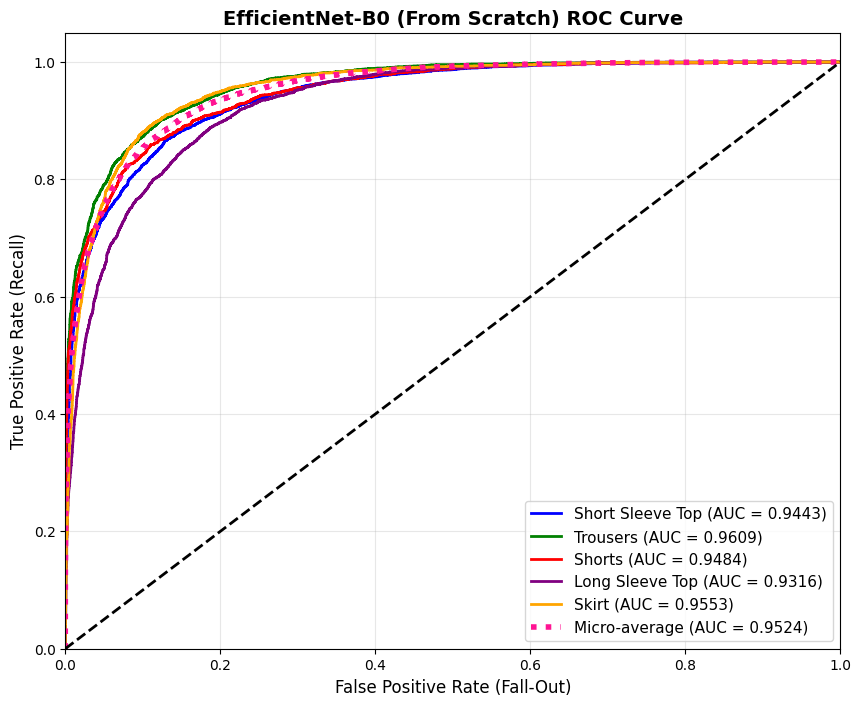

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_curve, auc, accuracy_score
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ==========================================
# 4. METRICS & ROC EVALUATION SCRIPT (EfficientNet-B0 Scratch)
# ==========================================
print("Evaluating EfficientNet-B0 (From Scratch) on the Test Set...")

# Optional: If you restarted your Kaggle notebook, uncomment the next two lines to load your best weights!
# state_dict = torch.load("effnet_b0_scratch_best.pth")
# model_effnet_scratch.load_state_dict(state_dict)

# 1. Put the model in evaluation mode
model_effnet_scratch.eval()

all_preds = []
all_labels = []
all_probs = [] 

# 2. Run the test set without tracking gradients
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_effnet_scratch(images)
        
        # Sigmoid converts raw logits to percentages (Crucial for Multi-Label!)
        probs = torch.sigmoid(outputs)
        
        # Apply the 0.5 threshold to get the hard 1s and 0s
        preds = (probs > 0.5).float()
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# 3. Stack arrays for scikit-learn
all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# 4. Calculate the Metrics
class_names = ["Short Sleeve Top", "Trousers", "Shorts", "Long Sleeve Top", "Skirt"]

micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
micro_prec = precision_score(all_labels, all_preds, average='micro', zero_division=0)
micro_recall = recall_score(all_labels, all_preds, average='micro', zero_division=0)
final_accuracy = accuracy_score(all_labels, all_preds) # Exact Match Ratio

# 5. Print exactly matching your formatting
print("\n" + "="*45)
print("🚀 PROJECT METRICS (EfficientNet-B0 Scratch)")
print("="*45)
print(f"Micro Precision: {micro_prec:.4f}")
print(f"Micro Recall:    {micro_recall:.4f}")
print(f"Micro F1-Score:  {micro_f1:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")
print("="*45)

print("\nPer-Category Breakdown:")
# Generate the multi-label classification report
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=class_names, 
    zero_division=0
)
print(report)

# ==========================================
# 6. PLOT ROC CURVES
# ==========================================
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Calculate and plot ROC for each individual class
for i in range(5):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

# Calculate and plot the Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', lw=4, 
         label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

# Graph Formatting
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('EfficientNet-B0 (From Scratch) ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Save the plot securely to your Kaggle working directory
plt.savefig("/kaggle/working/effnet_b0_scratch_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()